In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("zomato.csv",encoding='latin1')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

<Axes: xlabel='Votes', ylabel='Density'>

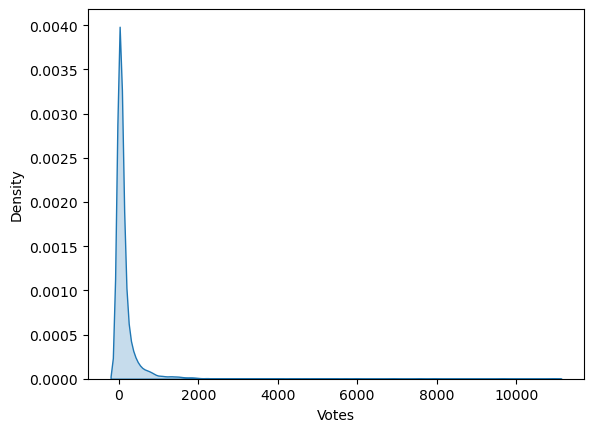

In [5]:
sns.kdeplot(df['Votes'],fill=True)

In [6]:
df2 = pd.read_csv("tested.csv")
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


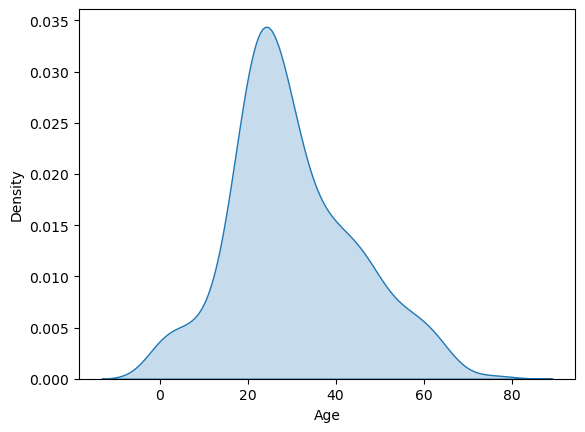

In [7]:
sns.kdeplot(df2['Age'],fill=True)
plt.show()

In [8]:
df2['SibSp'].value_counts()

SibSp
0    283
1    110
2     14
3      4
4      4
8      2
5      1
Name: count, dtype: int64

<Axes: xlabel='SibSp', ylabel='count'>

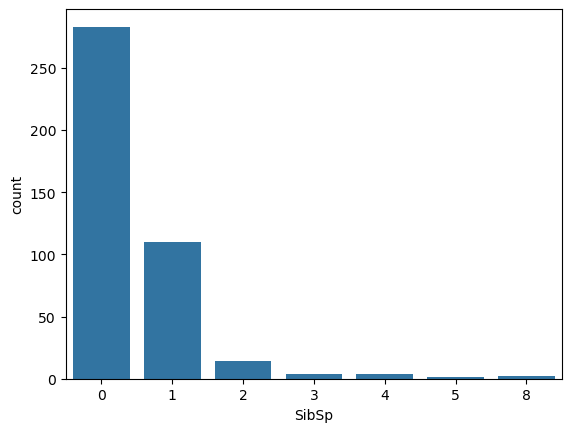

In [9]:
sns.countplot(x = df2['SibSp'],data=df2)

In [10]:
df3 = pd.read_csv('StressLevelDataset.csv')
df3.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [11]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()
df3['depression_transformed'] = pt.fit_transform(df3[['depression']])


<Axes: xlabel='depression', ylabel='Density'>

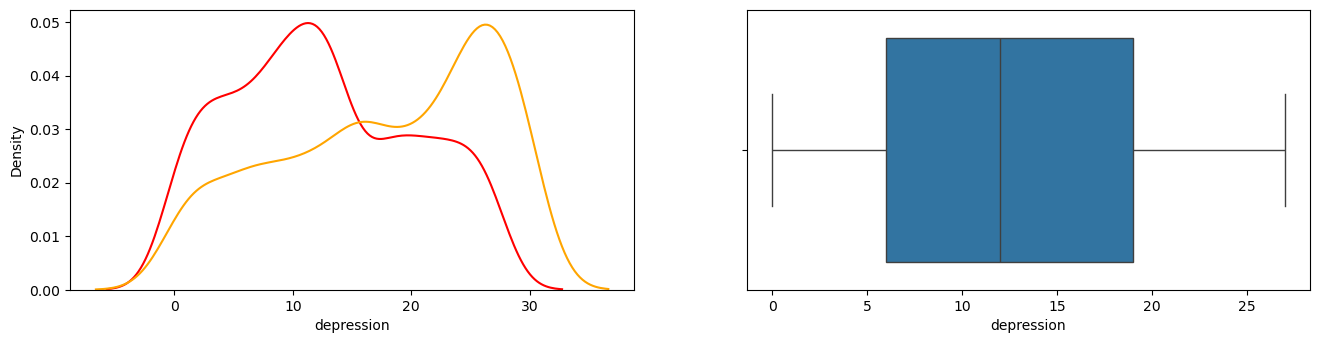

In [12]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.kdeplot(df3['depression'],color='red')

plt.subplot(2,2,2)
sns.boxplot(x = df3['depression'])

plt.subplot(2,2,1)
sns.kdeplot(df3['self_esteem'],color='orange')

# plt.subplot(2,2,4)
# sns.boxplot(x = df3['self_esteem'])

<Axes: xlabel='depression', ylabel='Density'>

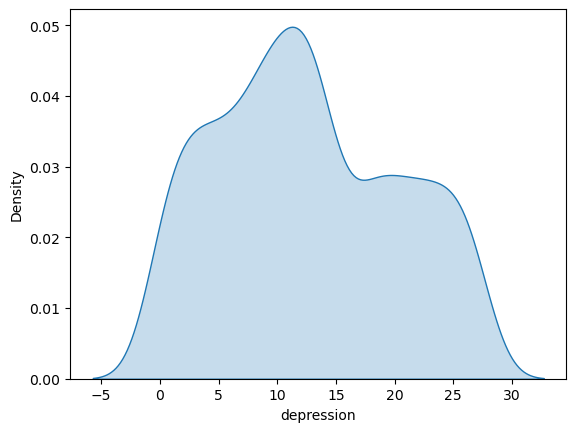

In [13]:
sns.kdeplot(df3['depression'],fill=True)

In [14]:
print(df3['depression'].mean() + df3['depression'].std())
print(df3['depression'].mean() - df3['depression'].std())

20.28246290050057
4.828446190408519


In [15]:
df4 = df3[(df3['depression'] > 4.8) | (df3['depression'] < 20.28)]

In [21]:
df4.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level,depression_transformed
0,14,20,0,11,2,1,2,4,2,3,...,3,2,3,3,2,3,3,2,1,-0.080385
1,15,8,1,15,5,3,1,4,3,1,...,1,4,1,5,1,4,5,5,2,0.405578
2,12,18,1,14,2,1,2,2,2,2,...,2,3,3,2,2,3,2,2,1,0.288601
3,16,12,1,15,4,3,1,3,4,2,...,2,4,1,4,1,4,4,5,2,0.405578
4,16,28,0,7,2,3,5,1,3,2,...,4,3,1,2,1,5,0,5,1,-0.629164


In [20]:
df4.columns.value_counts().sum()

np.int64(22)

<Axes: xlabel='anxiety_level', ylabel='Density'>

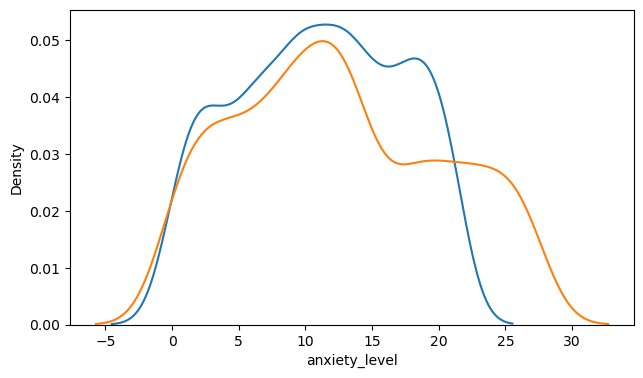

In [29]:
plt.figure(figsize=(16,9))
plt.subplot(2,2,1)
sns.kdeplot(df4['anxiety_level'])

plt.subplot(2,2,1)
sns.kdeplot(df4['depression'])